1. Обрати унікальний датасет з https://archive.ics.uci.edu/datasets , який відповідає наступним вимогам:
Dataset Characteristics: Multivariate
Attribute Characteristics: Categorical, Integer, Real
Number of Attributes: at least 2 integers/real
Has Missing Values: Yes
Був обраний і завантажений датасет Auto MPG. Оскільки заголовки стовпців містилися в окремому файлі, було використано column_names, в який введено данні з відповідного файла. 
na_values='?' автоматично замінить знаки питання на NaN. Данні розділені пробілами, тому використовується sep=r'\s+'.


In [1]:
import piplite
await piplite.install(['pandas', 'seaborn', 'matplotlib', 'numpy'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

column_names = [
    'mpg', 'cylinders', 'displacement', 'horsepower', 
    'weight', 'acceleration', 'model_year', 'origin', 'car_name'
]

file_path = 'auto-mpg.data' 

df = pd.read_csv(
    file_path,
    names=column_names,
    sep=r'\s+',
    na_values='?',
    comment='\t'
)

2. Здійснити Data Cleaning
Пропуски було заповнено медіаною.

In [2]:
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

Перевірка

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


3. Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).
   
    scatter Plot залежності MPG від Weight (витрати палива від ваги автомобіля)

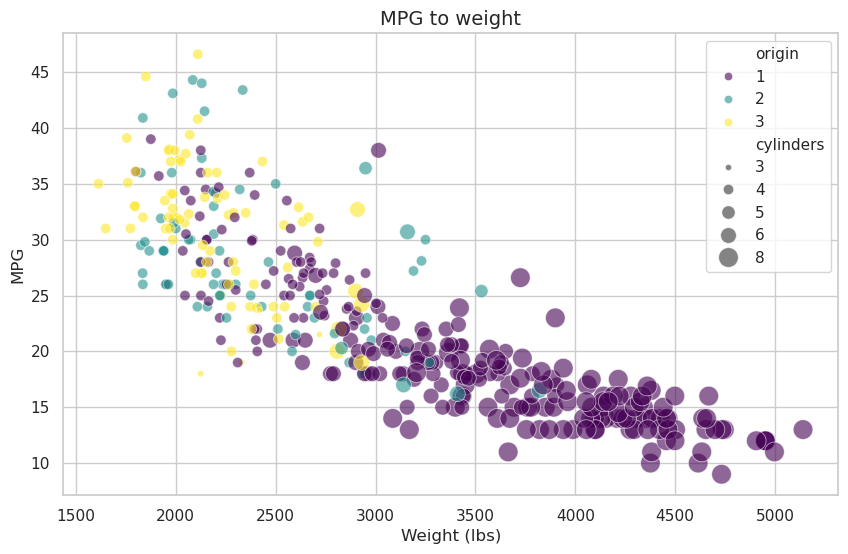

In [4]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='weight',          
    y='mpg',            
    hue='origin',         
    size='cylinders',   
    sizes=(20, 200),      
    alpha=0.6,           
    palette='viridis'     
)

plt.title('MPG to weight', fontsize=14)
plt.xlabel('Weight (lbs)', fontsize=12)
plt.ylabel('MPG', fontsize=12)
plt.legend(bbox_to_anchor=(1, 1)) 
plt.show()

  lineplot залежності MPG від model_year (як змінювалася паливна ефективність з роками)


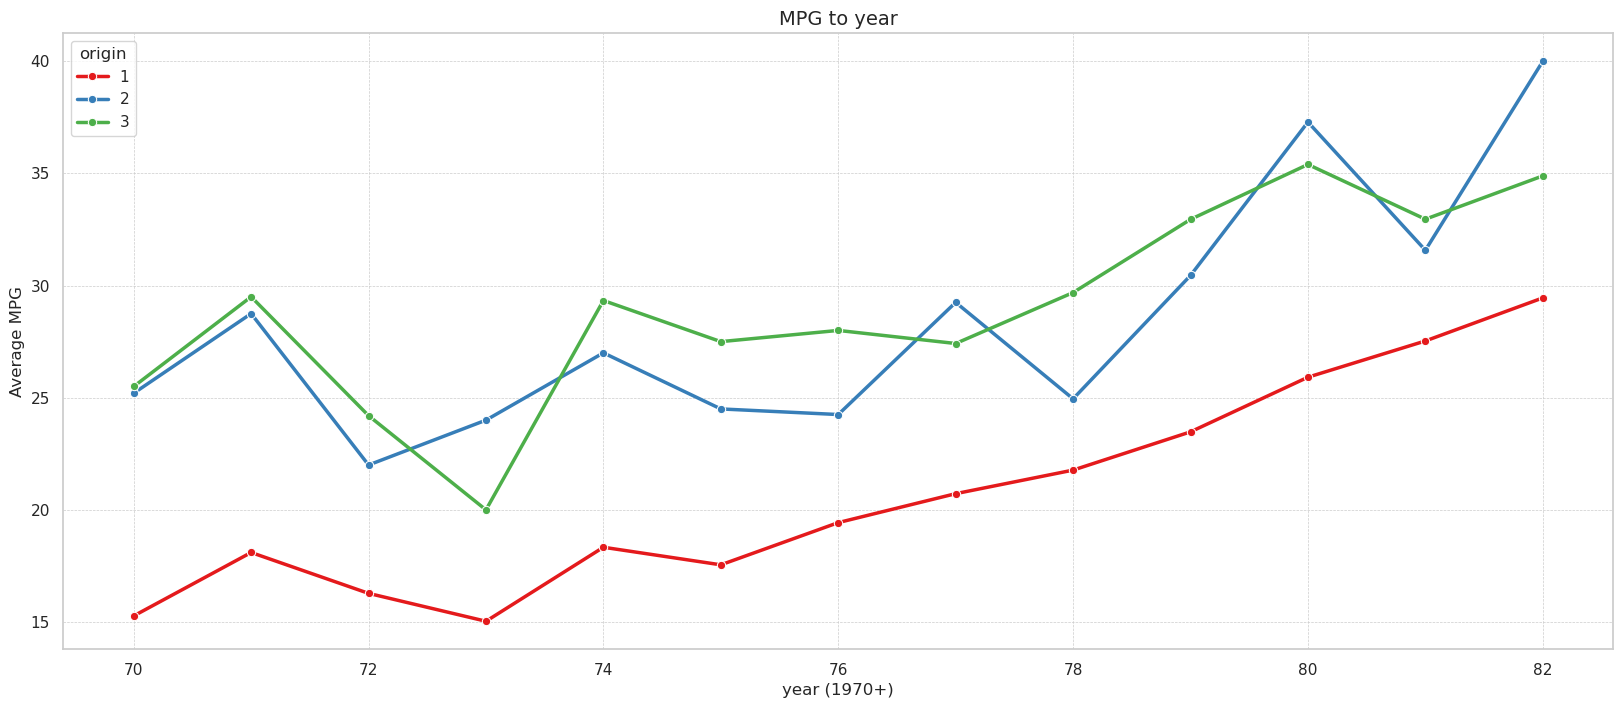

In [26]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(20, 8))

sns.lineplot(
    data=df, 
    x='model_year',       
    y='mpg',             
    hue='origin',        
    marker='o',        
    linewidth=2.5,       
    errorbar=None,       
    palette='Set1'     
)

plt.title('MPG to year', fontsize=14)
plt.xlabel('year (1970+)', fontsize=12)
plt.ylabel('Average MPG', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

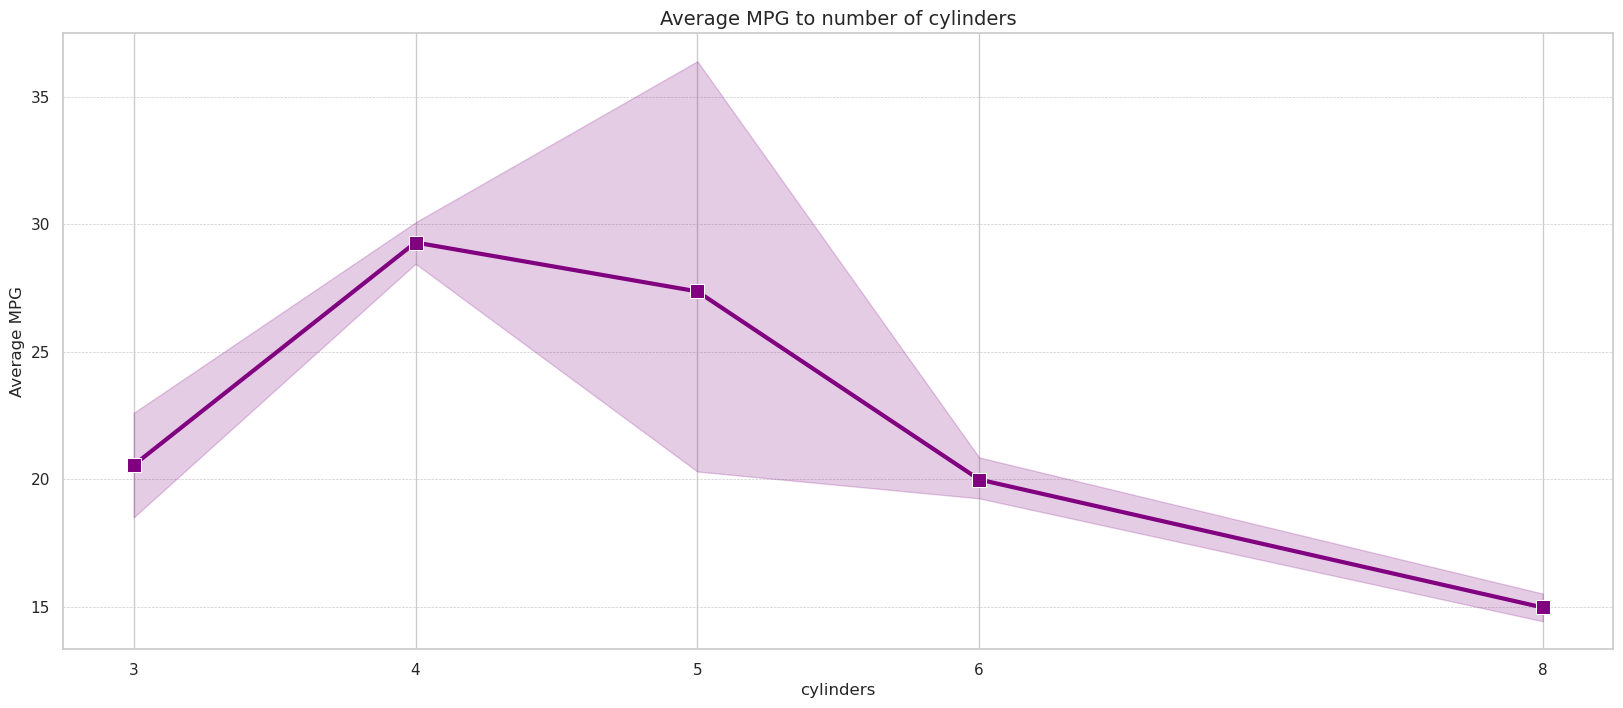

In [5]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(20, 8))

sns.lineplot(
    data=df, 
    x='cylinders',        
    y='mpg',             
    estimator='mean',     
    marker='s',          
    color='purple',       
    linewidth=3,
    errorbar=('ci', 95),
    markersize=10
)

plt.title('Average MPG to number of cylinders', fontsize=14)
plt.xlabel('cylinders', fontsize=12)
plt.ylabel('Average MPG', fontsize=12)
plt.xticks(df['cylinders'].unique()) 
plt.grid(True, axis='y', linestyle='--', linewidth=0.5)

4. Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.

За атрибут було взято MPG. Оскільки у датасті mpg коливається від 9 до 47 ми візьмемо інтервали [8-16], [16-24], [24-32], [32-40], [40-48].

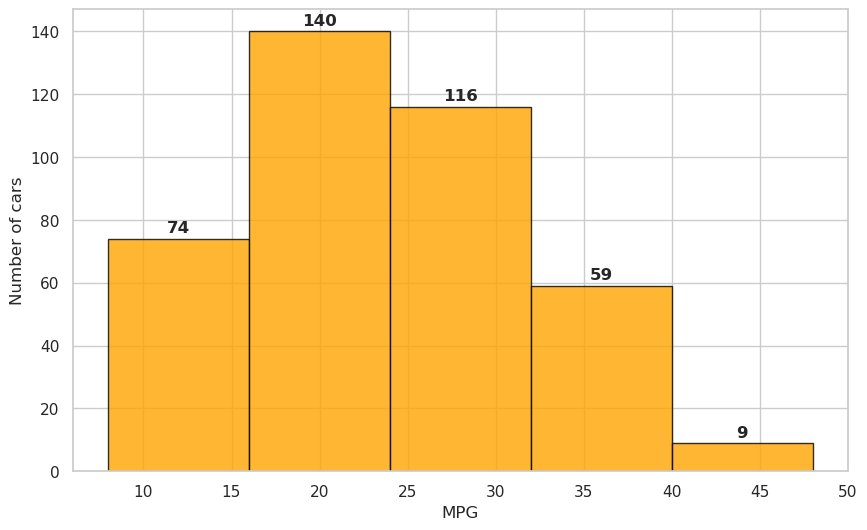

In [29]:
sns.set_theme(style="whitegrid")
bins = [8, 16, 24, 32, 40, 48]

plt.figure(figsize=(10, 6))

attribute = 'mpg'

n, bins, patches = plt.hist(
    df['mpg'], 
    bins=bins, 
    color='orange', 
    edgecolor='black', 
    alpha=0.8
)

for i in range(len(n)):
    plt.text(bins[i] + (bins[i+1]-bins[i])/2, n[i] + 1, int(n[i]), 
             ha='center', va='bottom', fontsize=12, fontweight='bold')


plt.xlabel('MPG', fontsize=12)
plt.ylabel('Number of cars', fontsize=12)

plt.show()

5. Збудувати графіки, використовуючи приклади, наведені у https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57 

    Heatmap. Кореляція всіх елементів

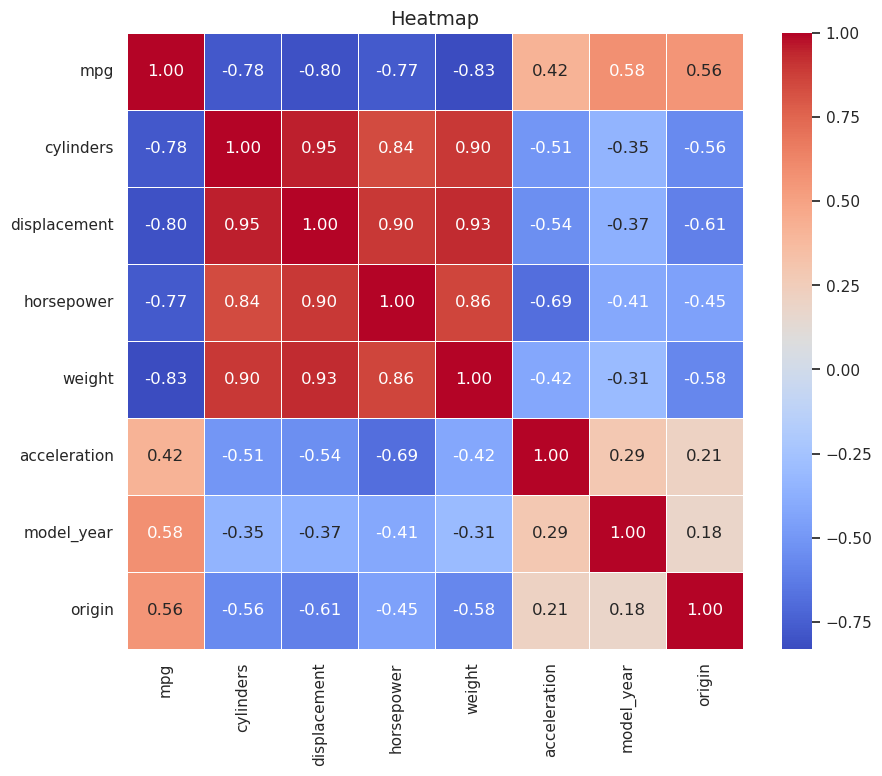

In [30]:
plt.figure(figsize=(10, 8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    linewidths=0.5,
    square=True
)

plt.title('Heatmap', fontsize=14)
plt.show()

     Pairplot. Кореляція всіх елементів

<Figure size 1000x800 with 0 Axes>

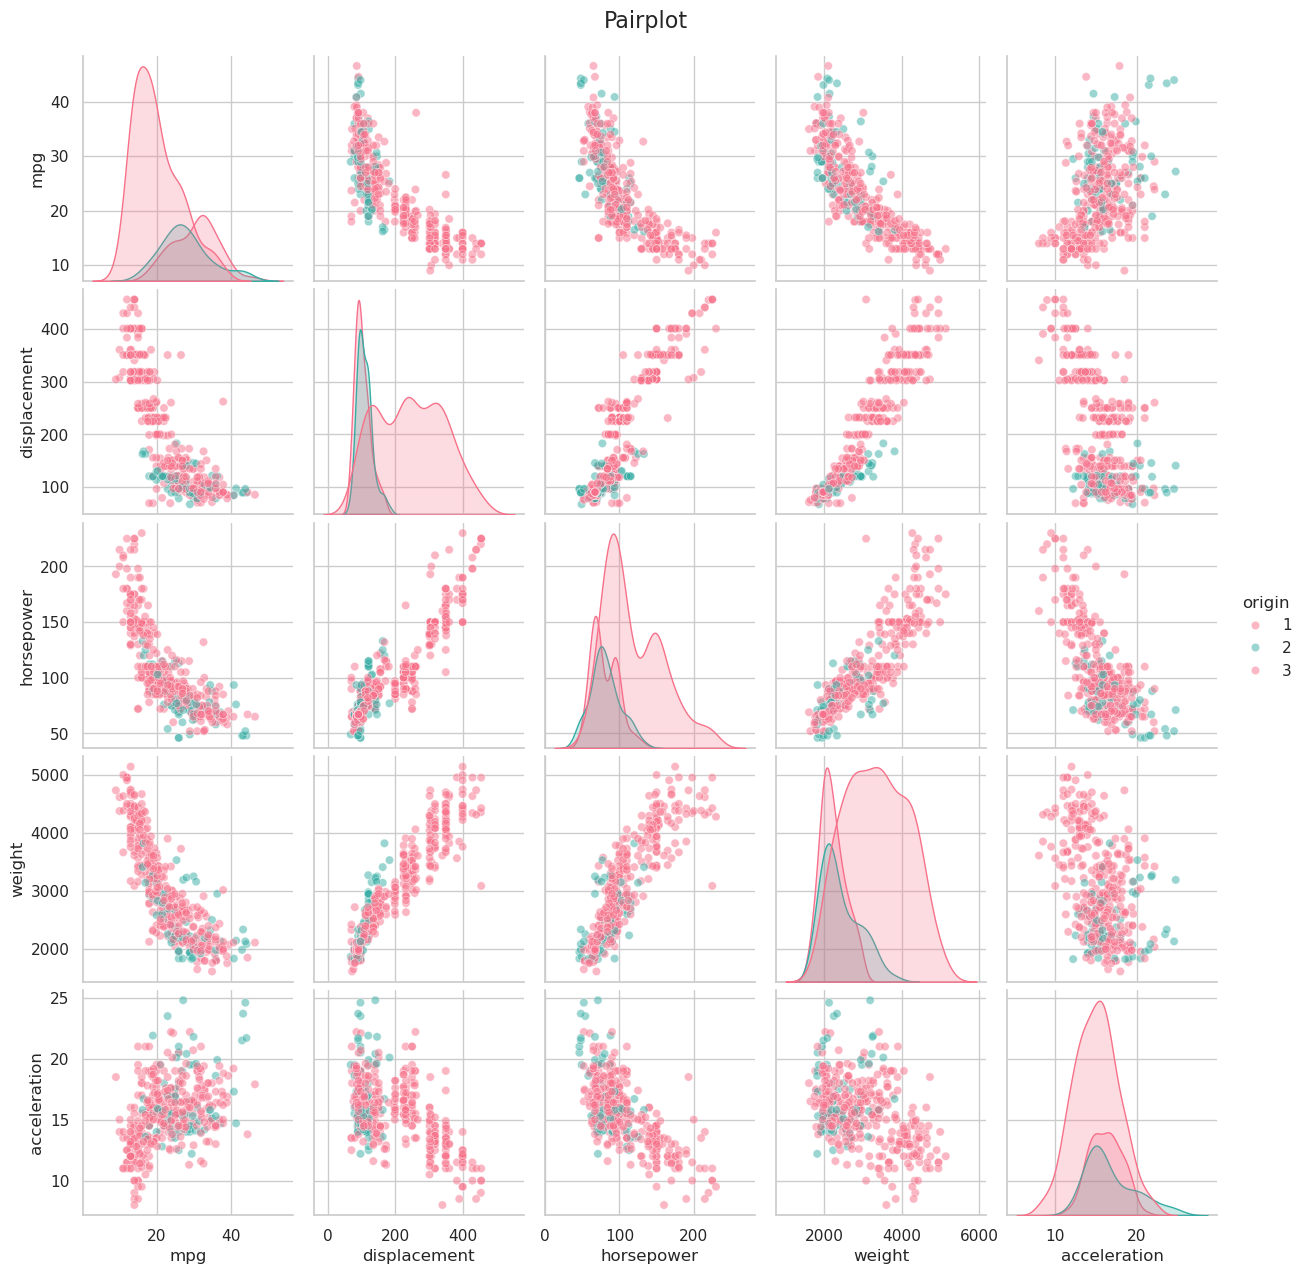

In [35]:
plt.figure(figsize=(10, 8))

cols_to_plot = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

sns.pairplot(
    df[cols_to_plot + ['origin']], 
    hue='origin', 
    palette='husl',
    diag_kind='kde', 
    plot_kws={'alpha': 0.5}
)

plt.suptitle('Pairplot', y=1.02, fontsize=16)
plt.show()

    Facet Grid. Аналіз зв регіоном походження

<Figure size 1000x800 with 0 Axes>

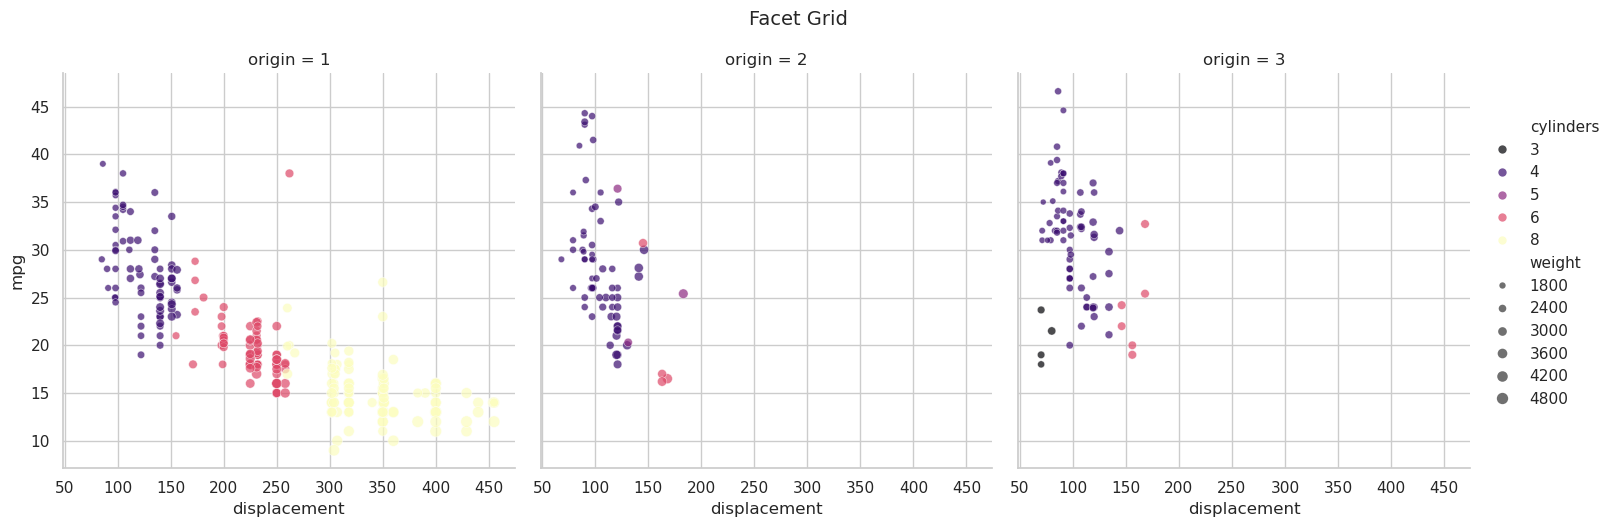

In [34]:
plt.figure(figsize=(10, 8))

g = sns.relplot(
    data=df, 
    x='displacement', y='mpg', 
    col='origin', hue='cylinders', 
    palette='magma', size='weight',
    kind='scatter', alpha=0.7
)

g.fig.suptitle('Facet Grid', y=1.05, fontsize=14)
plt.show()

6. Побудувати інші графіки, що покажуть корисну інформацію про датасет.
   Violin Plot. Порівняння розподілів MPG за регіонами

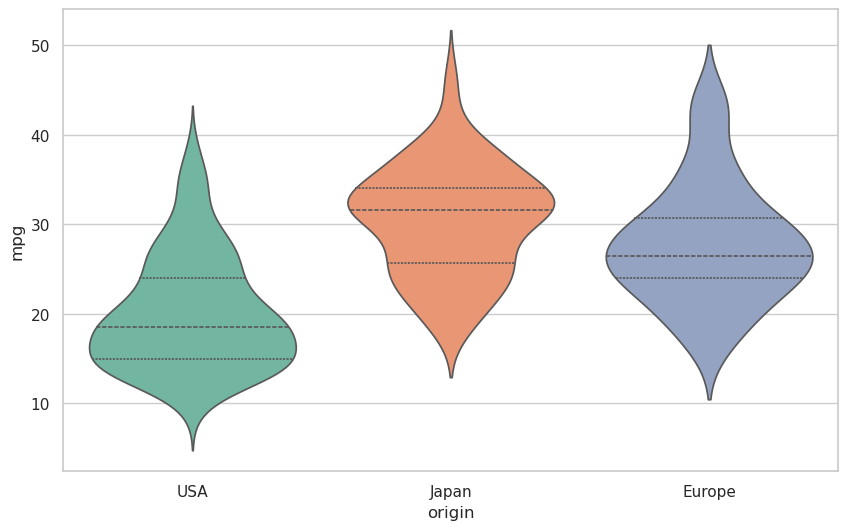

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_named = df.copy()

df_named['origin'] = df_named['origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_named, 
    x='origin', 
    y='mpg', 
    palette='Set2',
    hue='origin',
    inner="quartile"
)

plt.show()